# TP3 — Redes Neuronales

Este notebook implementa y evalúa un Perceptrón Multicapa (MLP) con descenso de gradiente con momentum.

**Secciones:**
1. Clasificación XOR
2. Clasificador de datos en R²
3. Clasificador de imágenes de fondo de ojo (ACRIMA)

## Configuración del entorno

Se clona el repositorio si se ejecuta en Google Colab y se agrega `src/` al path de Python.

In [1]:
## @brief Configura el entorno de ejecución (Colab o local).
#  Clona el repositorio si se ejecuta en Google Colab y ajusta el directorio de trabajo.
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('neural-network'):
        os.system('git clone https://github.com/DaniloDuque/neural-network.git')
    if os.path.basename(os.getcwd()) != 'neural-network':
        os.chdir('neural-network')
    os.system('git pull')
    sys.path.insert(0, os.path.abspath('src'))

## Dependencias e importaciones

In [2]:
## @brief Importa las dependencias del proyecto.
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from multilayer_perceptron import MultilayerPerceptron

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

Dispositivo: cpu


## Two Moons — Clasificación Binaria No Lineal

**Cambios respecto a la versión original:**
- `alpha` ajustado a `0.5` (antes `0.003`). Al normalizar los gradientes por `n` en `update_weights`, el learning rate efectivo ya no escala con el tamaño del dataset, por lo que un valor más alto es correcto y acelera la convergencia.
- Se fija `torch.manual_seed(42)` para reproducibilidad.
- Se aumentó levemente las épocas a `3000` (converge antes con el fix).

Error final: 0.0060  |  Accuracy: 99.3%


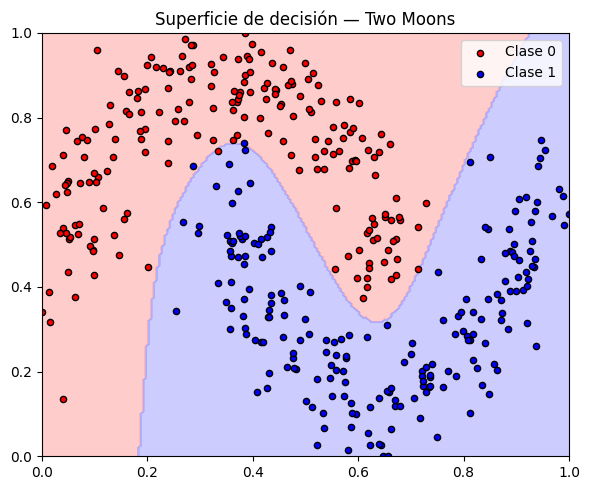

In [3]:
torch.manual_seed(7)

X_np, y_np = make_moons(n_samples=400, noise=0.15, random_state=42)
X_np = (X_np - X_np.min(0)) / (X_np.max(0) - X_np.min(0))
X = torch.FloatTensor(X_np)
T = torch.FloatTensor(y_np).unsqueeze(1)

mlp = MultilayerPerceptron([2, 128, 1], alpha=1.5, gamma=0.95, max_weights=0.01)
errors, _ = mlp.train_mlp(50000, X, T)

acc = (mlp.predict(X).squeeze() == torch.tensor(y_np)).float().mean().item()
print(f'Error final: {errors[-1]:.4f}  |  Accuracy: {acc*100:.1f}%')    

# --- Superficie de decisión ---
h = 0.005
xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
Z = mlp.predict(grid).numpy().reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.6)
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='red',  label='Clase 0', edgecolors='k', s=20)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='blue', label='Clase 1', edgecolors='k', s=20)
plt.title('Superficie de decisión — Two Moons')
plt.legend()
plt.tight_layout()
plt.show()